In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.ensemble import VotingClassifier

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.3f}'.format)

DATA = '/content/drive/MyDrive/Job_Fair 2026__Data_Science_Challenge/'
members_train = pd.read_csv(DATA + 'member_stats_training.csv')
matches_train = pd.read_csv(DATA + 'clan_matches_training.csv')
members_test  = pd.read_csv(DATA + 'member_stats_test.csv')
matches_test  = pd.read_csv(DATA + 'clan_matches_test.csv')

print(f'members_train : {members_train.shape}')
print(f'matches_train : {matches_train.shape}')
print(f'members_test  : {members_test.shape}')
print(f'matches_test  : {matches_test.shape}')
print(f'\nTarget distribution:\n{matches_train["clan_winner"].value_counts(normalize=True).round(4)}')

members_train : (291456, 15)
matches_train : (24288, 5)
members_test  : (283752, 15)
matches_test  : (23646, 2)

Target distribution:
clan_winner
2   0.501
1   0.499
Name: proportion, dtype: float64


In [4]:
clan_results = {}
for _, row in matches_train.iterrows():
    clan_results[row['clan_1_id']] = 'winner' if row['clan_winner'] == 1 else 'loser'
    clan_results[row['clan_2_id']] = 'winner' if row['clan_winner'] == 2 else 'loser'
members_train['result'] = members_train['clan_id'].map(clan_results)

num_cols = [
    'days_active_last_28_days', 'days_active_last_7_days',
    'days_since_last_active', 'training_count_last_28_days',
    'clan_multiplier', 'avg_stars_top_11_players',
    'avg_stars_top_3_players', 'avg_training_bonus', 'cohort_day'
]
rows = []
for col in num_cols:
    w = members_train[members_train['result'] == 'winner'][col].mean()
    l = members_train[members_train['result'] == 'loser'][col].mean()
    rows.append({'feature': col, 'winner_mean': w, 'loser_mean': l,
                 'diff_%': (w - l) / abs(l) * 100})
pd.DataFrame(rows).sort_values('diff_%', key=abs, ascending=False)

,feature,winner_mean,loser_mean,diff_%
2,days_since_last_active,4.813,6.039,-20.303
3,training_count_last_28_days,143.694,120.315,19.431
7,avg_training_bonus,8.554,7.862,8.792
1,days_active_last_7_days,5.625,5.356,5.018
0,days_active_last_28_days,22.478,21.506,4.521
8,cohort_day,1265.342,1216.330,4.030
5,avg_stars_top_11_players,5.850,5.679,3.002
6,avg_stars_top_3_players,6.727,6.542,2.829
4,clan_multiplier,2.692,2.663,1.059


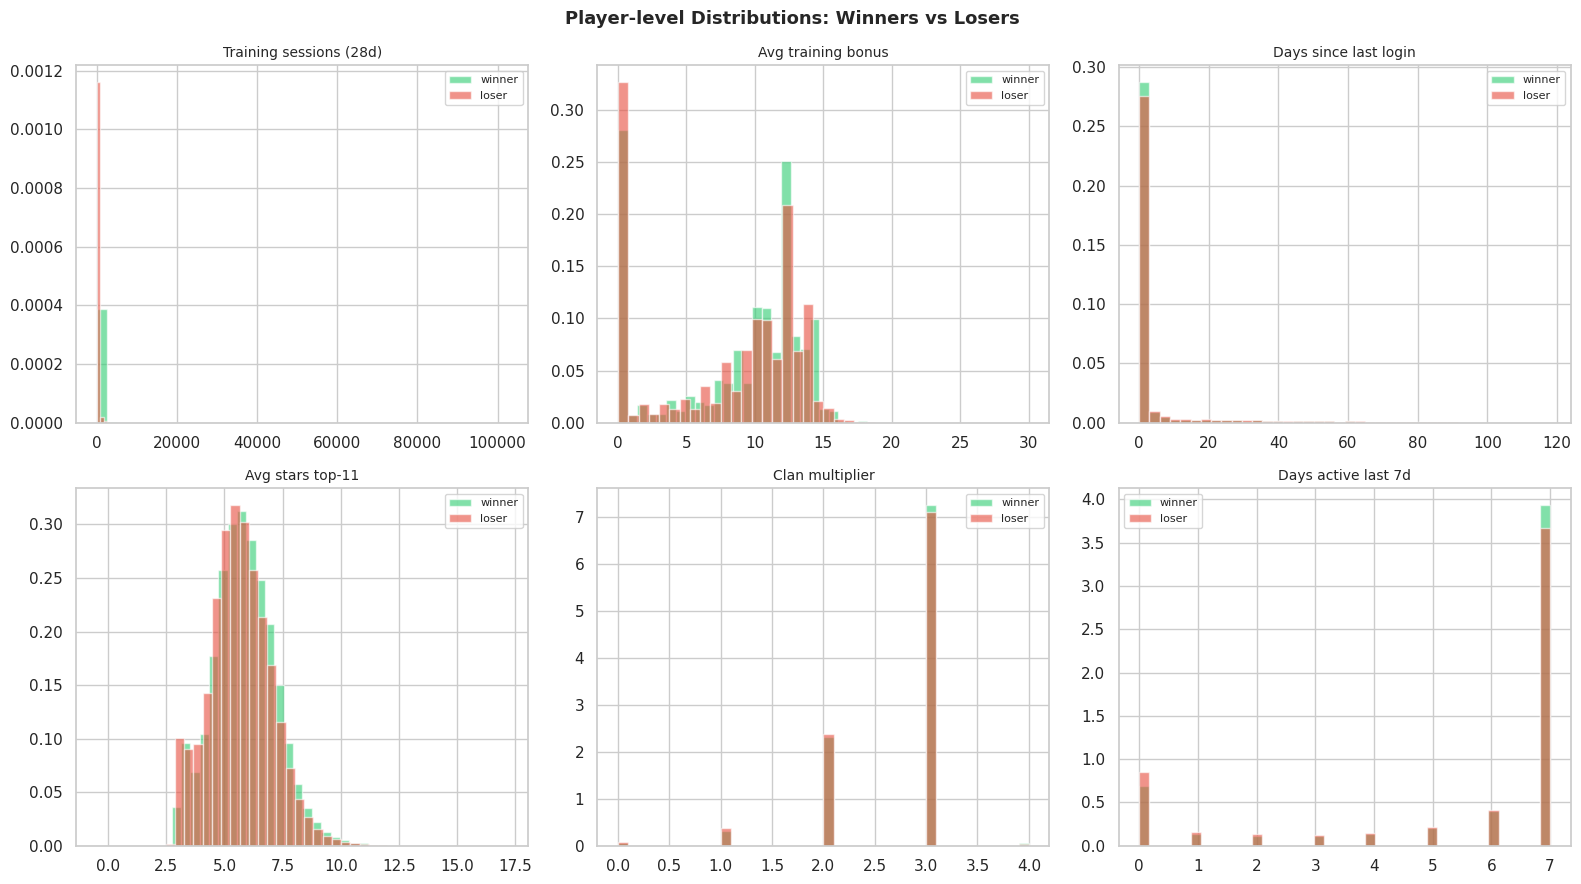

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
focus = [
    ('training_count_last_28_days', 'Training sessions (28d)'),
    ('avg_training_bonus',           'Avg training bonus'),
    ('days_since_last_active',        'Days since last login'),
    ('avg_stars_top_11_players',      'Avg stars top-11'),
    ('clan_multiplier',               'Clan multiplier'),
    ('days_active_last_7_days',       'Days active last 7d'),
]
for ax, (col, label) in zip(axes.flat, focus):
    for res, color in [('winner', '#2ecc71'), ('loser', '#e74c3c')]:
        vals = members_train[members_train['result'] == res][col].dropna()
        ax.hist(vals, bins=40, alpha=0.6, label=res, color=color, density=True)
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8)
plt.suptitle('Player-level Distributions: Winners vs Losers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
pen = members_train.groupby('clan_id').apply(lambda d: pd.Series({
    'ghost_count':    (d['days_since_last_active'] > 14).sum(),
    'inactive_count': (d['days_since_last_active'] > 7).sum(),
    'full_attendance': int(d['days_since_last_active'].max() == 0),
    'all_active_7':    int(d['days_active_last_7_days'].min() >= 1),
    'result':          d['result'].iloc[0]
})).reset_index()

print('=== Win rate by GHOST count (>14 days inactive) ===')
print(pen.groupby('ghost_count').apply(
    lambda d: pd.Series({'clans': len(d), 'win_rate': (d['result'] == 'winner').mean()})
).round(3).to_string())

print('\n=== Win rate: full attendance vs not ===')
print(pen.groupby('full_attendance').apply(
    lambda d: pd.Series({'clans': len(d), 'win_rate': (d['result'] == 'winner').mean()})
).round(3).to_string())

=== Win rate by GHOST count (>14 days inactive) ===
                clans  win_rate
ghost_count                    
0           29396.000     0.534
1           10469.000     0.453
2            5691.000     0.446
3            2142.000     0.444
4             559.000     0.390
5             162.000     0.463
6             157.000     0.439

=== Win rate: full attendance vs not ===
                    clans  win_rate
full_attendance                    
0               31203.000     0.466
1               17373.000     0.561


In [7]:
bonus_agg = members_train.groupby('clan_id').agg(
    min_bonus=('avg_training_bonus', 'min'),
    std_bonus=('avg_training_bonus', 'std'),
    result=('result', 'first')
).reset_index()

bonus_agg['min_bonus_tier'] = pd.cut(
    bonus_agg['min_bonus'],
    bins=[-0.1, 0.05, 3, 8, 12, 18.5],
    labels=['0 (none)', '0-3', '3-8', '8-12', '12+']
)

print('=== Win rate by MIN training bonus (weakest member) ===')
print(bonus_agg.groupby('min_bonus_tier', observed=True).apply(
    lambda d: pd.Series({'clans': len(d), 'win_rate': (d['result'] == 'winner').mean()})
).round(3).to_string())

=== Win rate by MIN training bonus (weakest member) ===
                   clans  win_rate
min_bonus_tier                    
0 (none)       29141.000     0.451
0-3             2603.000     0.546
3-8             6300.000     0.560
8-12            9312.000     0.588
12+             1220.000     0.588


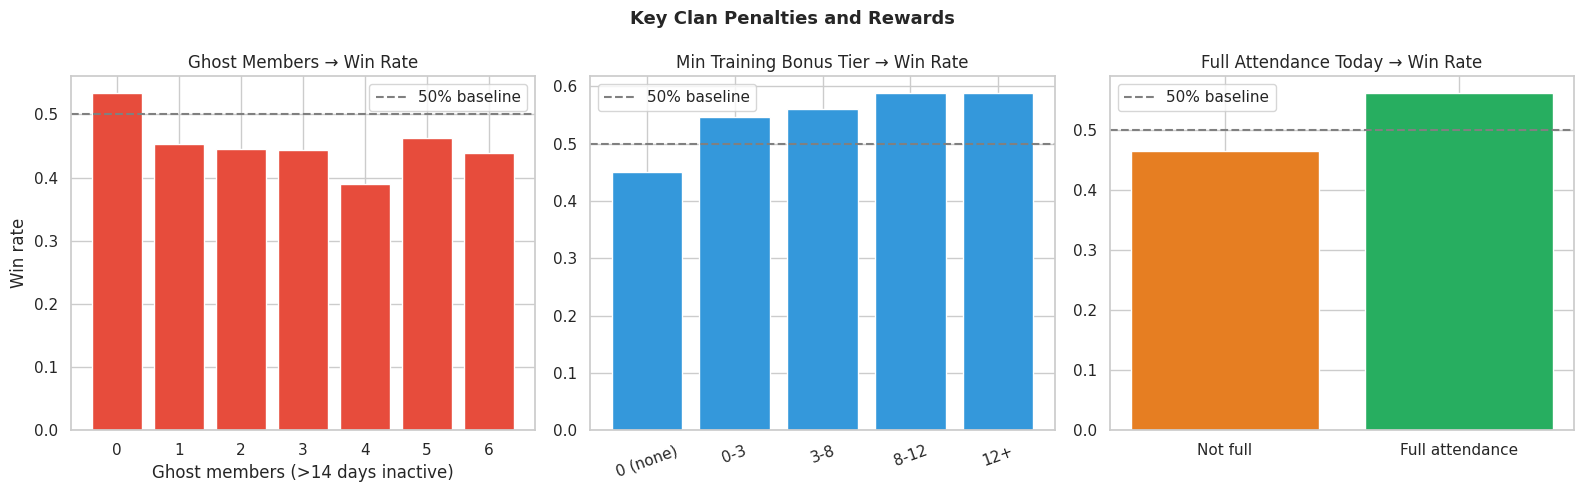

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ghost_wr = pen.groupby('ghost_count').apply(
    lambda d: (d['result'] == 'winner').mean()).reset_index()
ghost_wr.columns = ['ghost_count', 'win_rate']
axes[0].bar(ghost_wr['ghost_count'], ghost_wr['win_rate'], color='#e74c3c', edgecolor='white')
axes[0].axhline(0.5, color='gray', linestyle='--', label='50% baseline')
axes[0].set_xlabel('Ghost members (>14 days inactive)')
axes[0].set_ylabel('Win rate')
axes[0].set_title('Ghost Members → Win Rate')
axes[0].legend()

wr_bonus = bonus_agg.groupby('min_bonus_tier', observed=True).apply(
    lambda d: (d['result'] == 'winner').mean()).reset_index()
wr_bonus.columns = ['tier', 'win_rate']
axes[1].bar(range(len(wr_bonus)), wr_bonus['win_rate'], color='#3498db', edgecolor='white')
axes[1].axhline(0.5, color='gray', linestyle='--', label='50% baseline')
axes[1].set_xticks(range(len(wr_bonus)))
axes[1].set_xticklabels(wr_bonus['tier'].astype(str), rotation=20)
axes[1].set_title('Min Training Bonus Tier → Win Rate')
axes[1].legend()

att_wr = pen.groupby('full_attendance').apply(
    lambda d: (d['result'] == 'winner').mean()).reset_index()
att_wr.columns = ['full_attendance', 'win_rate']
axes[2].bar(['Not full', 'Full attendance'], att_wr['win_rate'], color=['#e67e22', '#27ae60'], edgecolor='white')
axes[2].axhline(0.5, color='gray', linestyle='--', label='50% baseline')
axes[2].set_title('Full Attendance Today → Win Rate')
axes[2].legend()

plt.suptitle('Key Clan Penalties and Rewards', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
def build_clan_features(members_df: pd.DataFrame) -> pd.DataFrame:
    df = members_df.copy()

    df['weighted_quality']    = df['clan_multiplier'] * df['avg_stars_top_11_players']
    df['expected_score']      = df['clan_multiplier'] * 3   # max pts if every match won
    df['recency_ratio']       = df['days_active_last_7_days'] / (df['days_active_last_28_days'] / 4 + 0.01)
    df['training_efficiency'] = df['training_count_last_28_days'] / (df['days_active_last_28_days'] + 0.01)
    df['is_inactive']         = (df['days_since_last_active'] > 7).astype(int)
    df['is_ghost']            = (df['days_since_last_active'] > 14).astype(int)

    g = df.groupby('clan_id')

    agg = pd.DataFrame({
        # Activity
        'mean_days_active_28':      g['days_active_last_28_days'].mean(),
        'min_days_active_28':       g['days_active_last_28_days'].min(),
        'mean_days_active_7':       g['days_active_last_7_days'].mean(),
        'min_days_active_7':        g['days_active_last_7_days'].min(),
        'max_days_since_active':    g['days_since_last_active'].max(),
        'mean_days_since_active':   g['days_since_last_active'].mean(),
        'inactive_count':           g['is_inactive'].sum(),
        'ghost_count':              g['is_ghost'].sum(),
        'all_active_7':             g['days_active_last_7_days'].min().gt(0).astype(int),
        'full_attendance':          g['days_since_last_active'].max().eq(0).astype(int),
        'mean_recency_ratio':       g['recency_ratio'].mean(),
        'min_recency_ratio':        g['recency_ratio'].min(),
        # Training
        'mean_training_count':      g['training_count_last_28_days'].mean(),
        'min_training_count':       g['training_count_last_28_days'].min(),
        'std_training_count':       g['training_count_last_28_days'].std(),
        'training_efficiency':      g['training_efficiency'].mean(),
        'min_training_efficiency':  g['training_efficiency'].min(),
        # Bonus
        'mean_training_bonus':      g['avg_training_bonus'].mean(),
        'min_training_bonus':       g['avg_training_bonus'].min(),
        'max_training_bonus':       g['avg_training_bonus'].max(),
        'std_training_bonus':       g['avg_training_bonus'].std(),
        'bonus_cv':                 g['avg_training_bonus'].std() / (g['avg_training_bonus'].mean() + 0.01),
        # Quality
        'mean_stars_top11':         g['avg_stars_top_11_players'].mean(),
        'min_stars_top11':          g['avg_stars_top_11_players'].min(),
        'max_stars_top11':          g['avg_stars_top_11_players'].max(),
        'std_stars_top11':          g['avg_stars_top_11_players'].std(),
        'mean_stars_top3':          g['avg_stars_top_3_players'].mean(),
        # Multiplier & Expected Score
        'mean_multiplier':          g['clan_multiplier'].mean(),
        'max_multiplier':           g['clan_multiplier'].max(),
        'sum_multiplier':           g['clan_multiplier'].sum(),
        'sum_expected_score':       g['expected_score'].sum(),
        'sum_weighted_quality':     g['weighted_quality'].sum(),
        'mean_weighted_quality':    g['weighted_quality'].mean(),
        'max_weighted_quality':     g['weighted_quality'].max(),
        # Payment / experience
        'payer_ratio':              g['is_payer_lifetime'].apply(lambda x: (x == True).mean()),
        'whale_count':              g['dynamic_payment_segment'].apply(lambda x: (x == '4) Whale').sum()),
        'mean_cohort_day':          g['cohort_day'].mean(),
        # Interaction features (compound weakest-link)
        'bonus_x_activity':         (g['avg_training_bonus'].mean() * g['days_active_last_7_days'].mean()),
        'quality_x_activity':       (g['avg_stars_top_11_players'].mean() * g['days_active_last_7_days'].mean()),
        'min_bonus_x_min_activity': (g['avg_training_bonus'].min() * g['days_active_last_7_days'].min()),
        'exp_score_x_activity':     (g['expected_score'].sum() * g['days_active_last_7_days'].mean()),
    })
    return agg

clan_agg_train = build_clan_features(members_train)
clan_agg_test  = build_clan_features(members_test)
print('Clan features:', clan_agg_train.shape)
clan_agg_train.describe().T[['mean', 'std', 'min', 'max']].head(10)

Clan features: (48576, 41)


,mean,std,min,max
mean_days_active_28,21.992,5.704,0.000,28.000
min_days_active_28,11.722,11.261,0.000,28.000
mean_days_active_7,5.490,1.482,0.000,7.000
min_days_active_7,2.788,2.994,0.000,7.000
max_days_since_active,20.898,27.904,0.000,118.000
mean_days_since_active,5.426,8.454,0.000,89.667
inactive_count,0.783,1.091,0.000,6.000
ghost_count,0.664,1.012,0.000,6.000
all_active_7,0.543,0.498,0.000,1.000
full_attendance,0.358,0.479,0.000,1.000


In [10]:
FEAT_COLS = clan_agg_train.columns.tolist()

def make_match_features(matches_df: pd.DataFrame, clan_agg: pd.DataFrame) -> pd.DataFrame:
    c1 = clan_agg.reindex(matches_df['clan_1_id'].values)
    c2 = clan_agg.reindex(matches_df['clan_2_id'].values)
    c1.index = matches_df.index
    c2.index = matches_df.index
    diff = c1.subtract(c2)
    diff.columns = [f'diff_{col}' for col in FEAT_COLS]
    return diff.reset_index(drop=True)

X_train = make_match_features(matches_train, clan_agg_train)
y_train = (matches_train['clan_winner'] == 1).astype(int).values
X_test  = make_match_features(matches_test, clan_agg_test)

# Symmetry augmentation: (c2-c1, flipped label) doubles training data and enforces antisymmetry
X_flip = -X_train.copy()
y_flip = 1 - y_train
X_aug  = pd.concat([X_train, X_flip], ignore_index=True)
y_aug  = np.concatenate([y_train, y_flip])

print(f'Match features   : {X_train.shape}')
print(f'Augmented train  : {X_aug.shape}')

Match features   : (24288, 41)
Augmented train  : (48576, 41)


In [11]:
xgb_params = dict(
    n_estimators=600,
    max_depth=4,
    learning_rate=0.04,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=1,
    reg_alpha=0.1,
    reg_lambda=1.5,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

lgb_params = dict(
    n_estimators=600,
    max_depth=4,
    learning_rate=0.04,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

xgb_model = xgb.XGBClassifier(**xgb_params)
lgb_model = lgb.LGBMClassifier(**lgb_params)

print('Models initialised.')

Models initialised.


In [12]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_scores, lgb_scores, ens_scores = [], [], []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr_raw = X_train.iloc[tr_idx]
    y_tr_raw = y_train[tr_idx]

    # Augment only the training fold
    X_tr = pd.concat([X_tr_raw, -X_tr_raw], ignore_index=True)
    y_tr = np.concatenate([y_tr_raw, 1 - y_tr_raw])

    X_val, y_val = X_train.iloc[val_idx], y_train[val_idx]

    xgb_model.fit(X_tr, y_tr)
    lgb_model.fit(X_tr, y_tr)

    p_xgb = xgb_model.predict_proba(X_val)[:, 1]
    p_lgb = lgb_model.predict_proba(X_val)[:, 1]
    p_ens = (p_xgb + p_lgb) / 2

    s_xgb = accuracy_score(y_val, (p_xgb >= 0.5).astype(int))
    s_lgb = accuracy_score(y_val, (p_lgb >= 0.5).astype(int))
    s_ens = accuracy_score(y_val, (p_ens >= 0.5).astype(int))

    xgb_scores.append(s_xgb)
    lgb_scores.append(s_lgb)
    ens_scores.append(s_ens)

    print(f'Fold {fold+1}:  XGB={s_xgb:.4f}  LGB={s_lgb:.4f}  Ensemble={s_ens:.4f}')

print(f'\nMean XGB       : {np.mean(xgb_scores):.4f} ± {np.std(xgb_scores):.4f}')
print(f'Mean LGB       : {np.mean(lgb_scores):.4f} ± {np.std(lgb_scores):.4f}')
print(f'Mean Ensemble  : {np.mean(ens_scores):.4f} ± {np.std(ens_scores):.4f}')

Fold 1:  XGB=0.5865  LGB=0.5836  Ensemble=0.5815
Fold 2:  XGB=0.5626  LGB=0.5626  Ensemble=0.5624
Fold 3:  XGB=0.5965  LGB=0.5984  Ensemble=0.6042
Fold 4:  XGB=0.5917  LGB=0.5864  Ensemble=0.5899
Fold 5:  XGB=0.5880  LGB=0.5845  Ensemble=0.5874

Mean XGB       : 0.5851 ± 0.0118
Mean LGB       : 0.5831 ± 0.0116
Mean Ensemble  : 0.5851 ± 0.0136


In [13]:
# Retrain on full augmented dataset for final predictions
xgb_model.fit(X_aug, y_aug)
lgb_model.fit(X_aug, y_aug)
print('Final models trained on full augmented dataset.')

Final models trained on full augmented dataset.


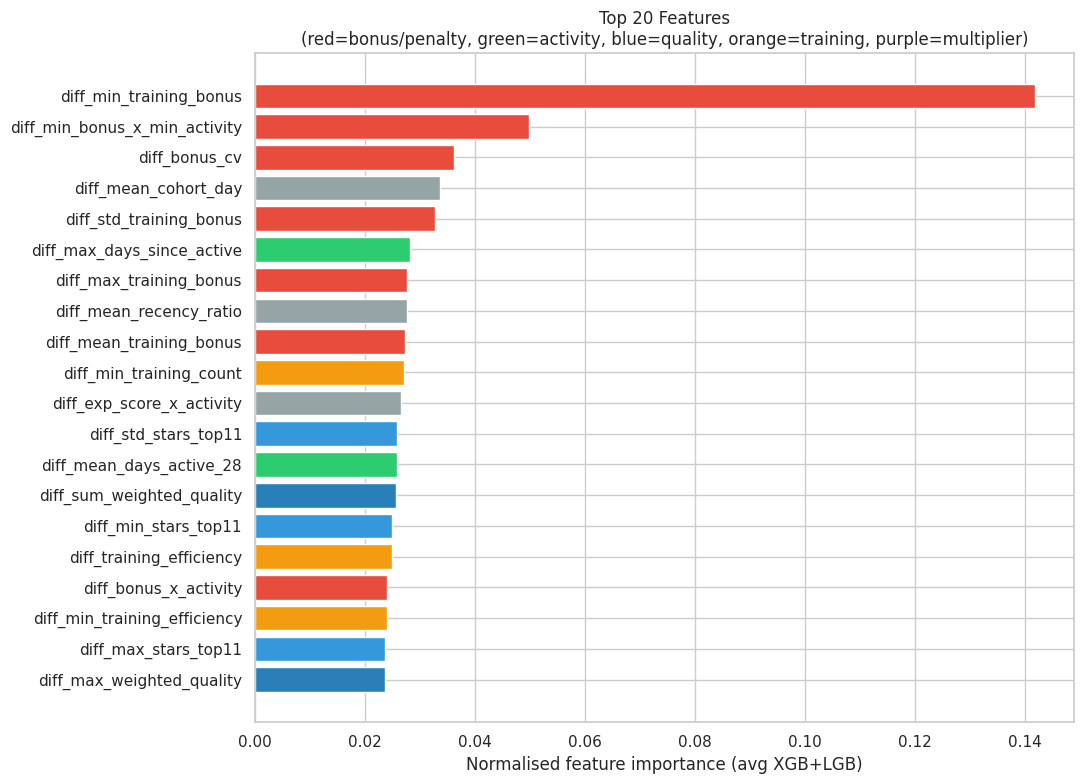

In [14]:
imp_xgb = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
imp_lgb = pd.Series(lgb_model.feature_importances_, index=X_train.columns)

# Normalise and average
imp_avg = (imp_xgb / imp_xgb.sum() + imp_lgb / imp_lgb.sum()) / 2
imp_avg = imp_avg.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 8))
top20 = imp_avg.head(20)
color_map = {
    'bonus': '#e74c3c',
    'ghost': '#c0392b',
    'inactive': '#c0392b',
    'attend': '#27ae60',
    'active': '#2ecc71',
    'star': '#3498db',
    'quality': '#2980b9',
    'train': '#f39c12',
    'expected': '#8e44ad',
    'multiplier': '#9b59b6',
}
colors = []
for f in top20.index:
    c = '#95a5a6'
    for kw, col in color_map.items():
        if kw in f:
            c = col
            break
    colors.append(c)

ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1])
ax.set_xlabel('Normalised feature importance (avg XGB+LGB)')
ax.set_title('Top 20 Features\n(red=bonus/penalty, green=activity, blue=quality, orange=training, purple=multiplier)')
plt.tight_layout()
plt.show()

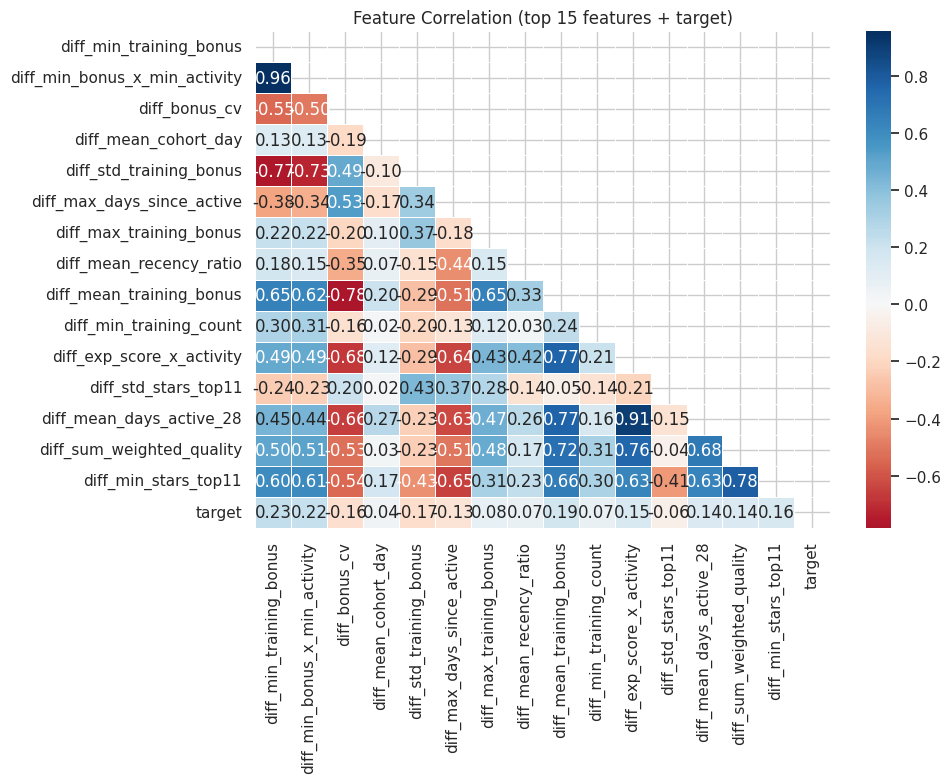

In [15]:
top_feats = imp_avg.head(15).index.tolist()
corr_df = X_train[top_feats].assign(target=y_train).corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.zeros_like(corr_df.values, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr_df, mask=mask, cmap='RdBu', center=0,
            annot=True, fmt='.2f', linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation (top 15 features + target)')
plt.tight_layout()
plt.show()

In [16]:
p_xgb_test = xgb_model.predict_proba(X_test)[:, 1]
p_lgb_test = lgb_model.predict_proba(X_test)[:, 1]
p_ens_test = (p_xgb_test + p_lgb_test) / 2

predicted_clan_winner = np.where(p_ens_test >= 0.5, 1, 2)

submission = pd.DataFrame({
    'clan_1_id': matches_test['clan_1_id'],
    'clan_2_id': matches_test['clan_2_id'],
    'predicted_clan_winner': predicted_clan_winner
})
submission.to_csv('clan_winner_predictions.csv', index=False)

print(f'Saved {len(submission)} predictions')
print(submission['predicted_clan_winner'].value_counts())
submission.head(10)

Saved 23646 predictions
predicted_clan_winner
2    11938
1    11708
Name: count, dtype: int64


,clan_1_id,clan_2_id,predicted_clan_winner
0,clan_5029188,clan_5045813,2
1,clan_5016270,clan_5010361,2
2,clan_5024341,clan_5015291,1
3,clan_5025374,clan_5002293,1
4,clan_5036635,clan_5029684,1
5,clan_5008910,clan_5033381,2
6,clan_5021926,clan_5029744,2
7,clan_5035595,clan_5005752,1
8,clan_5015113,clan_5027408,1
9,clan_5014326,clan_5014687,1
